# scOPE end-to-end -- BRCA (TCGA-BRCA)

Two-phase scOPE workflow applied to breast cancer:

1. **Phase 1** -- learn a latent space from TCGA BRCA bulk RNA-seq (~1 100
   tumour samples) and train mutation classifiers (PIK3CA, TP53, CDH1, ...).
2. **Phase 2** -- project Wu et al. 2021 TNBC scRNA-seq (GSE176078, ~100 K
   cells, 26 patients) into the bulk latent space and infer per-cell mutation
   probabilities.

**Data notes:**
- Bulk expression: UCSC Xena TCGA BRCA `HiSeqV2_PANCAN`
  (log2(norm_count + 1), genes x samples).
- Mutations: TCGA MC3 PanCanAtlas MAF (shared with CRC notebook).
  Filtered to BRCA samples by matching against bulk obs_names.
- scRNA-seq: Wu et al. 2021 GSE176078 TNBC atlas -- one .h5 file per patient,
  downloaded via GEO HTTPS. Cell-type annotations from companion metadata file.
- PAM50 subtype from TCGA Xena clinical matrix (optional -- used for annotation
  only; pipeline runs without it).

**Note on subtype heterogeneity:**
TCGA BRCA spans luminal A/B, HER2-enriched, and TNBC subtypes. Mutation
frequencies (especially PIK3CA vs. TP53) differ substantially by subtype.
For a focused analysis, restrict `adata_bulk` to a single PAM50 subtype
using the `PAM50` annotation added in section 3.


## 1. Imports & paths

In [1]:
import os
import gzip
import shutil
import tarfile

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import requests

from scope import BulkPipeline, SingleCellPipeline
from scope.visualization import (
    compute_umap,
    plot_mutation_probabilities,
    plot_scree,
    plot_mutation_heatmap,
)


In [2]:
# -- Paths ------------------------------------------------------------------
BASE_DIR   = "/Users/ashforda/Desktop/Pathways + Omics/scOPE/scOPE_project_overhaul/scOPE/data"
BULK_DIR   = os.path.join(BASE_DIR, "TCGA_BRCA")
SC_DIR     = os.path.join(BASE_DIR, "BRCA_scRNA")
MODELS_DIR = os.path.join(BASE_DIR, "..", "models", "BRCA")

for d in [BULK_DIR, SC_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

# -- File locations ---------------------------------------------------------
brca_expr_path = os.path.join(BULK_DIR, "TCGA_BRCA_HiSeqV2_PANCAN.tsv.gz")
# GDC TCGA-CDR file is an Excel workbook (.xlsx), not a TSV
brca_clin_path = os.path.join(BULK_DIR, "TCGA_BRCA_clinical.xlsx")
# MC3 MAF is a shared PanCanAtlas resource -- place in BASE_DIR so it is
# downloaded once and reused across CRC / BRCA / SKCM notebooks.
mc3_path       = os.path.join(BASE_DIR, "mc3.v0.2.8.PUBLIC.xena.gz")
sc_h5_dir      = os.path.join(SC_DIR,   "h5_files")
# Will be set after extraction; None means metadata is unavailable
sc_meta_path   = None
os.makedirs(sc_h5_dir, exist_ok=True)


## 2. Download raw data

In [3]:
# -- UCSC Xena -- bulk RNA-seq (expression files still work) ---------------
XENA_BASE = "https://tcga.xenahubs.net/download"

if os.path.exists(brca_expr_path):
    print(f"  already present -- {os.path.basename(brca_expr_path)}")
else:
    print(f"  downloading {os.path.basename(brca_expr_path)} ...")
    r = requests.get(f"{XENA_BASE}/TCGA.BRCA.sampleMap/HiSeqV2_PANCAN.gz",
                     stream=True, timeout=300)
    r.raise_for_status()
    with open(brca_expr_path, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print(f"  done -> {brca_expr_path}")

# -- TCGA-CDR clinical data (PAM50) via GDC publications endpoint ----------
# The GDC endpoint returns an Excel workbook (TCGA-CDR-SupplementalTableS1.xlsx).
# Save with .xlsx extension and read with pd.read_excel() in section 3.
if os.path.exists(brca_clin_path):
    print(f"  already present -- {os.path.basename(brca_clin_path)}")
else:
    print("  downloading TCGA-CDR clinical file (xlsx) ...")
    try:
        r = requests.get(
            "https://api.gdc.cancer.gov/data/1b5f413e-a8d1-4d10-92eb-7c4ae739ed81",
            stream=True, timeout=300,
        )
        r.raise_for_status()
        with open(brca_clin_path, "wb") as fh:
            for chunk in r.iter_content(1 << 20):
                fh.write(chunk)
        print(f"  done -> {brca_clin_path}")
    except Exception as e:
        print(f"  WARNING: clinical download failed ({e})")
        print("  PAM50 annotation will be skipped -- pipeline still runs fine.")
        brca_clin_path = None


  already present -- TCGA_BRCA_HiSeqV2_PANCAN.tsv.gz
  already present -- TCGA_BRCA_clinical.xlsx


In [4]:
# -- MC3 PanCanAtlas MAF -- all TCGA cancer types, one file (~200 MB) -------
# Hosted on Xena pancanatlas hub. Shared resource -- skip if already present
# from the CRC notebook (check BASE_DIR and TCGA_CRC/ as fallback).
_crc_mc3 = os.path.join(BASE_DIR, "TCGA_CRC", "mc3.v0.2.8.PUBLIC.xena.gz")
if not os.path.exists(mc3_path) and os.path.exists(_crc_mc3):
    import shutil
    shutil.copy(_crc_mc3, mc3_path)
    print(f"  copied MC3 from CRC directory -> {mc3_path}")
elif not os.path.exists(mc3_path):
    print("Downloading MC3 MAF (~200 MB) ...")
    r = requests.get(
        "https://pancanatlas.xenahubs.net/download/mc3.v0.2.8.PUBLIC.xena.gz",
        stream=True, timeout=600,
    )
    r.raise_for_status()
    with open(mc3_path, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print(f"  done -> {mc3_path}")
else:
    print(f"  already present -- {os.path.basename(mc3_path)}")


  already present -- mc3.v0.2.8.PUBLIC.xena.gz


In [5]:
# -- GEO -- GSE176078: download series tar for metadata only --------------
# The series tar.gz contains per-patient metadata.csv but NOT the h5 files.
# The h5 files come from GSE176078_RAW.tar (downloaded in the next cell).

series_tar = os.path.join(SC_DIR, "GSE176078_Wu_etal_2021_BRCA_scRNASeq.tar.gz")

if not os.path.exists(series_tar):
    print("Downloading GSE176078 series tar (~metadata, ~10 MB) ...")
    url = ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE176078&format=file"
           "&file=GSE176078%5FWu%5Fetal%5F2021%5FBRCA%5FscRNASeq%2Etar%2Egz")
    r = requests.get(url, stream=True, timeout=600)
    r.raise_for_status()
    with open(series_tar, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print(f"  done -> {series_tar}")
else:
    print(f"  already present -- {os.path.basename(series_tar)}")

# Extract if not already done
meta_candidates = [
    os.path.join(root, f)
    for root, _, files in os.walk(sc_h5_dir)
    for f in files
    if "metadata" in f.lower() and f.endswith((".csv", ".csv.gz", ".txt", ".txt.gz"))
]
if not meta_candidates:
    print("Extracting series tar for metadata ...")
    os.makedirs(sc_h5_dir, exist_ok=True)
    with tarfile.open(series_tar, "r:gz") as tf:
        tf.extractall(sc_h5_dir)
    print("  done")
    meta_candidates = [
        os.path.join(root, f)
        for root, _, files in os.walk(sc_h5_dir)
        for f in files
        if "metadata" in f.lower() and f.endswith((".csv", ".csv.gz", ".txt", ".txt.gz"))
    ]

if meta_candidates:
    sc_meta_path = meta_candidates[0]
    print(f"Metadata file: {sc_meta_path}")
else:
    print("WARNING: no metadata file found -- cell-type annotation will be unavailable.")
    sc_meta_path = None


  already present -- GSE176078_Wu_etal_2021_BRCA_scRNASeq.tar.gz
Metadata file: /Users/ashforda/Desktop/Pathways + Omics/scOPE/scOPE_project_overhaul/scOPE/data/BRCA_scRNA/h5_files/CID3948/metadata.csv


In [6]:
# -- GEO -- GSE176078_RAW.tar: per-patient h5 files -----------------------
# Step 1: Download RAW.tar if not present
FTP_SUPPL    = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176078/suppl/"
raw_tar_path = os.path.join(SC_DIR, "GSE176078_RAW.tar")

if not os.path.exists(raw_tar_path):
    print("Downloading GSE176078_RAW.tar (~533 MB) ...")
    r = requests.get(FTP_SUPPL + "GSE176078_RAW.tar", timeout=1800, stream=True)
    r.raise_for_status()
    with open(raw_tar_path, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print("  done")
else:
    print(f"  RAW.tar already present ({os.path.getsize(raw_tar_path) / 1e6:.0f} MB)")

# Step 2: Inspect tar contents (first 20 members) to detect actual format
print("\n-- TAR contents (first 20 members) --")
with tarfile.open(raw_tar_path, "r:") as tar:
    all_members = tar.getmembers()
    for m in all_members[:20]:
        print(f"  {m.name}  ({m.size:,} bytes)")
    print(f"  ... ({len(all_members)} total members)")

    exts = set()
    for m in all_members:
        _, ext = os.path.splitext(m.name)
        exts.add(ext.lower())
print(f"\nUnique extensions in tar: {sorted(exts)}")


  RAW.tar already present (558 MB)

-- TAR contents (first 20 members) --
  GSM5354513_CID3586.tar.gz  (19,721,175 bytes)
  GSM5354514_CID3838.tar.gz  (22,497,691 bytes)
  GSM5354515_CID3921.tar.gz  (17,440,017 bytes)
  GSM5354516_CID3941.tar.gz  (2,396,529 bytes)
  GSM5354517_CID3946.tar.gz  (1,604,982 bytes)
  GSM5354518_CID3948.tar.gz  (6,500,301 bytes)
  GSM5354519_CID3963.tar.gz  (14,792,215 bytes)
  GSM5354520_CID4040.tar.gz  (17,381,308 bytes)
  GSM5354521_CID4066.tar.gz  (25,475,894 bytes)
  GSM5354522_CID4067.tar.gz  (16,881,308 bytes)
  GSM5354523_CID4290A.tar.gz  (32,099,279 bytes)
  GSM5354524_CID4398.tar.gz  (9,715,190 bytes)
  GSM5354525_CID44041.tar.gz  (8,519,284 bytes)
  GSM5354526_CID4461.tar.gz  (1,442,973 bytes)
  GSM5354527_CID4463.tar.gz  (7,772,944 bytes)
  GSM5354528_CID4465.tar.gz  (2,808,564 bytes)
  GSM5354529_CID4471.tar.gz  (55,925,058 bytes)
  GSM5354530_CID4495.tar.gz  (40,022,423 bytes)
  GSM5354531_CID44971.tar.gz  (44,964,324 bytes)
  GSM5354532_CID449

In [7]:
# -- Extract GSE176078_RAW.tar: outer tar -> per-sample .tar.gz -> custom MTX
# Per-sample layout after extraction:
#   sc_h5_dir/CIDxxxx/
#     count_matrix_sparse.mtx
#     count_matrix_barcodes.tsv
#     count_matrix_genes.tsv
#     metadata.csv
import io

os.makedirs(sc_h5_dir, exist_ok=True)

with tarfile.open(raw_tar_path, "r:") as outer:
    for om in outer.getmembers():
        if not om.name.endswith(".tar.gz"):
            continue
        sample_id = os.path.basename(om.name).split("_", 1)[1].replace(".tar.gz", "")
        dest_dir  = os.path.join(sc_h5_dir, sample_id)
        if os.path.isdir(dest_dir) and os.listdir(dest_dir):
            print(f"  already extracted -- {sample_id}")
            continue
        print(f"  unpacking {sample_id} ...", end=" ", flush=True)
        os.makedirs(dest_dir, exist_ok=True)
        inner_bytes = outer.extractfile(om).read()
        with tarfile.open(fileobj=io.BytesIO(inner_bytes), mode="r:gz") as inner:
            for im in inner.getmembers():
                if not im.isfile():
                    continue
                bn   = os.path.basename(im.name)
                dest = os.path.join(dest_dir, bn)
                if os.path.exists(dest):
                    continue
                im.name = bn
                inner.extract(im, path=dest_dir)
        print("done")

# Detect sample dirs by presence of any .mtx file (not standard 10x names)
sample_dirs = sorted(set([
    root
    for root, _, files in os.walk(sc_h5_dir)
    for f in files if f.endswith(".mtx")
]))
print(f"\n{len(sample_dirs)} sample directories ready")
if sample_dirs:
    print(f"Example contents of {os.path.basename(sample_dirs[0])}: {os.listdir(sample_dirs[0])}")


  already extracted -- CID3586
  already extracted -- CID3838
  already extracted -- CID3921
  already extracted -- CID3941
  already extracted -- CID3946
  already extracted -- CID3948
  already extracted -- CID3963
  already extracted -- CID4040
  already extracted -- CID4066
  already extracted -- CID4067
  already extracted -- CID4290A
  already extracted -- CID4398
  already extracted -- CID44041
  already extracted -- CID4461
  already extracted -- CID4463
  already extracted -- CID4465
  already extracted -- CID4471
  already extracted -- CID4495
  already extracted -- CID44971
  already extracted -- CID44991
  already extracted -- CID4513
  already extracted -- CID4515
  already extracted -- CID45171
  already extracted -- CID4523
  already extracted -- CID4530N
  already extracted -- CID4535

27 sample directories ready
Example contents of CID3586: ['CID3586', 'count_matrix_barcodes.tsv', 'metadata.csv', 'count_matrix_sparse.mtx', 'count_matrix_genes.tsv']


## 3. Load & prepare bulk RNA-seq

Xena `HiSeqV2_PANCAN` files are **genes x samples**. After transposing, sample
barcodes are already trimmed to 15 chars (`TCGA-XX-XXXX-01`).


In [8]:
# -- Peek -------------------------------------------------------------------
peek = pd.read_csv(brca_expr_path, sep="\t", index_col=0, nrows=3)
print(f"Peek : {peek.shape}   cols[:4] = {peek.columns[:4].tolist()}")


Peek : (3, 1218)   cols[:4] = ['TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01', 'TCGA-BH-A0BT-01']


In [9]:
df_bulk = pd.read_csv(brca_expr_path, sep="\t", index_col=0).T   # samples x genes
# Keep only primary tumour barcodes (positions 13:15 == "01")
df_bulk = df_bulk[df_bulk.index.str[13:15] == "01"]

adata_bulk = ad.AnnData(
    X   = df_bulk.values.astype(np.float32),
    obs = pd.DataFrame(index=df_bulk.index),
    var = pd.DataFrame(index=df_bulk.columns),
)
adata_bulk.var_names_make_unique()
print(f"Bulk loaded : {adata_bulk.n_obs} tumour samples x {adata_bulk.n_vars} genes")


Bulk loaded : 1097 tumour samples x 20530 genes


In [10]:
# -- Attach PAM50 subtype (optional) --------------------------------------
# TCGA-CDR Excel file has PAM50 in the 'BRCA' sheet under a column that
# varies by CDR version. We search all sheets and all columns.
if brca_clin_path and os.path.exists(brca_clin_path):
    try:
        xl      = pd.ExcelFile(brca_clin_path, engine="openpyxl")
        pam50_col, clin = None, None
        for sheet in xl.sheet_names:
            df = xl.parse(sheet, index_col=0)
            hit = next((c for c in df.columns
                         if "pam50" in c.lower() or "subtype" in c.lower()), None)
            if hit:
                pam50_col, clin = hit, df
                print(f"  Found PAM50 column '{hit}' in sheet '{sheet}'")
                break
        if pam50_col:
            # Match on 12-char patient barcode (TCGA-XX-XXXX)
            clin.index = clin.index.astype(str).str[:12]
            bulk_12    = adata_bulk.obs_names.str[:12]
            pam50      = clin[pam50_col].reindex(bulk_12.values)
            adata_bulk.obs["PAM50"] = pam50.values
            print("PAM50 distribution:")
            print(adata_bulk.obs["PAM50"].value_counts())
        else:
            print("PAM50 column not found in any sheet -- skipping.")
            print(f"Available sheets: {xl.sheet_names}")
    except Exception as e:
        print(f"Clinical matrix unavailable ({e}) -- continuing without PAM50.")
else:
    print("Clinical file not available -- PAM50 annotation skipped.")


PAM50 column not found in any sheet -- skipping.
Available sheets: ['TCGA-CDR', 'TCGA-CDR_Notes', 'ExtraEndpoints', 'ExtraEndpoints_Notes', 'Table4_PHAssumptionTests', 'Table5_PHAssumptionTests', 'TSS_Info', 'Fig2EFG_AdditionalInfo']


In [11]:
# -- Sanity check -----------------------------------------------------------
X = adata_bulk.X
print(f"NaN : {np.isnan(X).sum()} | Inf : {np.isinf(X).sum()}")
print(f"Min : {np.nanmin(X):.3f} | Max : {np.nanmax(X):.3f}")
print(f"Neg : {(X < 0).sum()}  (expected for log2 data)")


NaN : 0 | Inf : 0
Min : -11.291 | Max : 20.454
Neg : 12173176  (expected for log2 data)


## 4. Build mutation label matrix

Using the TCGA MC3 PanCanAtlas MAF. BRCA samples are identified by matching
against `adata_bulk.obs_names` (15-char prefix), which avoids needing to
enumerate all BRCA TSS codes.


In [12]:
# -- Key BRCA driver genes --------------------------------------------------
BRCA_GENES = [
    # -- PI3K pathway -------------------------------------------------------
    "PIK3CA",   # ~35% -- most common, especially luminal
    "PIK3R1",   # regulatory subunit
    "PTEN",     # phosphatase / tumour suppressor
    "AKT1",     # E17K hotspot

    # -- TP53 ---------------------------------------------------------------
    "TP53",     # ~80% TNBC, ~10% luminal A

    # -- Cell adhesion / invasion -------------------------------------------
    "CDH1",     # E-cadherin -- lobular carcinoma hallmark

    # -- MAPK / HER2 pathway ------------------------------------------------
    "ERBB2",    # HER2 amplification / somatic mutation
    "ERBB3",
    "KRAS",
    "BRAF",

    # -- Transcription factors ----------------------------------------------
    "GATA3",    # ~10% luminal
    "RUNX1",
    "FOXA1",

    # -- DNA repair / genome stability --------------------------------------
    "BRCA1",    # germline + somatic
    "BRCA2",
    "PALB2",
    "ATM",

    # -- Chromatin remodeling -----------------------------------------------
    "KMT2C",    # MLL3
    "ARID1A",
    "MAP3K1",   # frequently mutated, luminal

    # -- Cell cycle ---------------------------------------------------------
    "RB1",
    "CCND1",
    "CDKN2A",
]
BRCA_GENES = list(dict.fromkeys(BRCA_GENES))
print(f"Targeting {len(BRCA_GENES)} BRCA driver genes")


Targeting 23 BRCA driver genes


In [13]:
KEEP_CLASSES = {
    "Missense_Mutation", "Nonsense_Mutation", "Frame_Shift_Del",
    "Frame_Shift_Ins", "In_Frame_Del", "In_Frame_Ins",
    "Splice_Site", "Translation_Start_Site", "Nonstop_Mutation",
}


In [14]:
# -- Load MC3, filter to BRCA by matching bulk obs_names -------------------
mc3 = pd.read_csv(mc3_path, sep="\t", low_memory=False)
print(f"MC3 raw : {len(mc3):,} rows   cols[:6]: {mc3.columns.tolist()[:6]}")

mc3 = mc3.rename(columns={
    "sample" : "Tumor_Sample_Barcode",
    "effect" : "Variant_Classification",
    "gene"   : "Hugo_Symbol",
})

# Filter to BRCA by matching against bulk 15-char barcodes
bulk_15_set = set(adata_bulk.obs_names.str[:15])
mc3["sample_id"] = mc3["Tumor_Sample_Barcode"].str[:15]
maf_brca = mc3[mc3["sample_id"].isin(bulk_15_set)].copy()
print(f"BRCA rows (pre-filter) : {len(maf_brca):,}   samples: {maf_brca['sample_id'].nunique()}")

maf_brca = maf_brca[maf_brca["Variant_Classification"].isin(KEEP_CLASSES)]
maf_all  = maf_brca[["sample_id", "Hugo_Symbol"]].dropna()
print(f"After coding filter    : {len(maf_all):,} variants   {maf_all['sample_id'].nunique()} samples")


MC3 raw : 2,907,335 rows   cols[:6]: ['sample', 'chr', 'start', 'end', 'reference', 'alt']
BRCA rows (pre-filter) : 92,036   samples: 789
After coding filter    : 60,396 variants   789 samples


In [15]:
# -- Build binary mutation matrix (samples x genes) ------------------------
mut_matrix = (
    maf_all[["sample_id", "Hugo_Symbol"]]
    .drop_duplicates()
    .assign(mutated=1)
    .pivot_table(index="sample_id", columns="Hugo_Symbol",
                 values="mutated", fill_value=0)
)
mut_matrix.columns.name = None
mut_matrix.index.name   = None

genes_present = [g for g in BRCA_GENES if g in mut_matrix.columns]
genes_missing = [g for g in BRCA_GENES if g not in mut_matrix.columns]
mutation_labels = mut_matrix[genes_present]

print(f"Mutation matrix : {mutation_labels.shape}")
print(f"Genes found     : {genes_present}")
if genes_missing:
    print(f"Genes missing   : {genes_missing}")


Mutation matrix : (789, 22)
Genes found     : ['PIK3CA', 'PIK3R1', 'PTEN', 'AKT1', 'TP53', 'CDH1', 'ERBB2', 'ERBB3', 'KRAS', 'BRAF', 'GATA3', 'RUNX1', 'FOXA1', 'BRCA1', 'BRCA2', 'PALB2', 'ATM', 'KMT2C', 'ARID1A', 'MAP3K1', 'RB1', 'CCND1']
Genes missing   : ['CDKN2A']


In [16]:
# -- Intersect bulk samples with mutation labels ---------------------------
# Both sides are already 15-char barcodes, but trim defensively.
bulk_15 = pd.Index(adata_bulk.obs_names.str[:15])
mut_15  = pd.Index(mutation_labels.index.str[:15])

shared_mask = bulk_15.isin(mut_15)
print(f"Bulk samples with MC3 calls : {shared_mask.sum()} / {adata_bulk.n_obs}")
assert shared_mask.sum() > 50, (
    f"Suspiciously few matches ({shared_mask.sum()}) -- check barcode formats:\n"
    f"  bulk : {adata_bulk.obs_names[:3].tolist()}\n"
    f"  MC3  : {mutation_labels.index[:3].tolist()}"
)

adata_bulk = adata_bulk[shared_mask].copy()
adata_bulk.obs["barcode_15"] = adata_bulk.obs_names.str[:15]

mut_reindexed       = mutation_labels.copy()
mut_reindexed.index = mut_reindexed.index.str[:15]
mut_reindexed       = mut_reindexed[~mut_reindexed.index.duplicated(keep="first")]
mutation_labels     = mut_reindexed.loc[adata_bulk.obs["barcode_15"]]
mutation_labels.index = adata_bulk.obs_names

print(f"\nMutation frequencies (top 20):")
print(mutation_labels.sum().sort_values(ascending=False).head(20))
mutation_labels.head()


Bulk samples with MC3 calls : 789 / 1097

Mutation frequencies (top 20):
PIK3CA    273.0
TP53      264.0
CDH1      102.0
GATA3      96.0
KMT2C      77.0
MAP3K1     66.0
PTEN       48.0
RUNX1      32.0
FOXA1      27.0
ARID1A     26.0
AKT1       24.0
PIK3R1     23.0
ERBB2      23.0
BRCA1      22.0
BRCA2      20.0
RB1        20.0
ATM        17.0
ERBB3      14.0
BRAF        7.0
PALB2       7.0
dtype: float64


,PIK3CA,PIK3R1,PTEN,AKT1,TP53,CDH1,ERBB2,ERBB3,KRAS,BRAF,...,FOXA1,BRCA1,BRCA2,PALB2,ATM,KMT2C,ARID1A,MAP3K1,RB1,CCND1
TCGA-AR-A5QQ-01,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-BH-A0BQ-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-BH-A0BT-01,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-BH-A0C7-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
TCGA-AC-A5XU-01,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Load single-cell data

In [17]:
# -- Load per-sample Wu et al. custom MTX format --------------------------
# Files: count_matrix_sparse.mtx, count_matrix_barcodes.tsv,
#        count_matrix_genes.tsv, metadata.csv
import scipy.io, scipy.sparse

sample_dirs = sorted(set([
    root
    for root, _, files in os.walk(sc_h5_dir)
    for f in files if f.endswith(".mtx")
]))

if not sample_dirs:
    raise FileNotFoundError(
        f"No .mtx files found under {sc_h5_dir}.\n"
        "Re-run the extraction cell above."
    )

print(f"Loading {len(sample_dirs)} samples ...")
adatas = []

for sdir in sample_dirs:
    sample_id = os.path.basename(sdir)

    mtx_path = os.path.join(sdir, "count_matrix_sparse.mtx")
    bar_path = os.path.join(sdir, "count_matrix_barcodes.tsv")
    gen_path = os.path.join(sdir, "count_matrix_genes.tsv")

    mat      = scipy.io.mmread(mtx_path).T.tocsr().astype("float32")
    barcodes = pd.read_csv(bar_path, header=None)[0].tolist()
    genes    = pd.read_csv(gen_path, header=None)[0].tolist()

    a = ad.AnnData(
        X   = mat,
        obs = pd.DataFrame(index=[f"{sample_id}_{bc}" for bc in barcodes]),
        var = pd.DataFrame(index=genes),
    )
    a.obs["sample_id"] = sample_id
    a.var_names_make_unique()

    # Attach per-sample metadata if present
    meta_path = os.path.join(sdir, "metadata.csv")
    if os.path.exists(meta_path):
        meta = pd.read_csv(meta_path, index_col=0)
        meta.index = [f"{sample_id}_{bc}" for bc in meta.index]
        shared = a.obs_names.intersection(meta.index)
        for col in meta.columns:
            a.obs[col] = meta[col].reindex(a.obs_names).values

    adatas.append(a)

adata_sc = ad.concat(adatas, join="inner")
adata_sc.var_names_make_unique()
print(f"SC raw : {adata_sc.n_obs:,} cells x {adata_sc.n_vars:,} genes")

# Show cell-type column if present
ct_col = next((c for c in adata_sc.obs.columns
               if "celltype" in c.lower() or "cell_type" in c.lower()), None)
if ct_col:
    print(f"\nCell type distribution ({ct_col}):")
    print(adata_sc.obs[ct_col].value_counts().head(12))


Loading 27 samples ...
SC raw : 200,128 cells x 29,733 genes

Cell type distribution (celltype_subset):
celltype_subset
T_cells_c1_CD4+_IL7R            15572
Cancer LumA SC                  15484
Cancer Cycling                  10718
T_cells_c4_CD8+_ZFP36           10126
T_cells_c0_CD4+_CCR7             9904
Endothelial ACKR1                9222
Cancer Basal SC                  8624
T_cells_c2_CD4+_T-regs_FOXP3     8492
Cancer Her2 SC                   7416
Plasmablasts                     7048
PVL Differentiated s3            6974
Cancer LumB SC                   6736
Name: count, dtype: int64


In [18]:
# -- Metadata already merged per-sample in the load cell above ------------
# This cell verifies the result and identifies the cell-type annotation column.
print(f"obs columns: {adata_sc.obs.columns.tolist()}")

ct_col = next((c for c in adata_sc.obs.columns
               if "celltype" in c.lower() or "cell_type" in c.lower()), None)
if ct_col:
    print(f"\nCell type column: '{ct_col}'")
    print(adata_sc.obs[ct_col].value_counts().head(12))
else:
    print("No cell_type column found. Available columns:", adata_sc.obs.columns.tolist())


obs columns: ['sample_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major']

Cell type column: 'celltype_subset'
celltype_subset
T_cells_c1_CD4+_IL7R            15572
Cancer LumA SC                  15484
Cancer Cycling                  10718
T_cells_c4_CD8+_ZFP36           10126
T_cells_c0_CD4+_CCR7             9904
Endothelial ACKR1                9222
Cancer Basal SC                  8624
T_cells_c2_CD4+_T-regs_FOXP3     8492
Cancer Her2 SC                   7416
Plasmablasts                     7048
PVL Differentiated s3            6974
Cancer LumB SC                   6736
Name: count, dtype: int64


In [19]:
# -- QC & normalisation ----------------------------------------------------
sc.pp.filter_genes(adata_sc, min_cells=10)
sc.pp.filter_cells(adata_sc, min_genes=100)
print(f"After QC : {adata_sc.n_obs:,} cells x {adata_sc.n_vars:,} genes")

# Log-normalise to match bulk units (log2(CPM+1))
sc.pp.normalize_total(adata_sc, target_sum=1e6)   # CPM
sc.pp.log1p(adata_sc, base=2)                      # log2(CPM+1)
print("Normalisation complete.")


After QC : 200,128 cells x 26,684 genes
Normalisation complete.


## 6. Gene overlap & sanity checks

In [20]:
overlap = set(adata_bulk.var_names) & set(adata_sc.var_names)
print(f"Bulk  : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
print(f"SC    : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")
print(f"Muts  : {mutation_labels.shape}")
print(f"Gene overlap : {len(overlap):,}")

X = adata_bulk.X
print(f"\nBulk NaN : {np.isnan(X).sum()} | Inf : {np.isinf(X).sum()}")
print(f"\nMutation frequencies:")
print(mutation_labels.sum().sort_values(ascending=False))
mutation_labels.head()


Bulk  : 789 samples x 20530 genes
SC    : 200128 cells x 26684 genes
Muts  : (789, 22)
Gene overlap : 16,214

Bulk NaN : 0 | Inf : 0

Mutation frequencies:
PIK3CA    273.0
TP53      264.0
CDH1      102.0
GATA3      96.0
KMT2C      77.0
MAP3K1     66.0
PTEN       48.0
RUNX1      32.0
FOXA1      27.0
ARID1A     26.0
AKT1       24.0
PIK3R1     23.0
ERBB2      23.0
BRCA1      22.0
BRCA2      20.0
RB1        20.0
ATM        17.0
ERBB3      14.0
BRAF        7.0
PALB2       7.0
KRAS        5.0
CCND1       1.0
dtype: float64


,PIK3CA,PIK3R1,PTEN,AKT1,TP53,CDH1,ERBB2,ERBB3,KRAS,BRAF,...,FOXA1,BRCA1,BRCA2,PALB2,ATM,KMT2C,ARID1A,MAP3K1,RB1,CCND1
TCGA-AR-A5QQ-01,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-BH-A0BQ-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-BH-A0BT-01,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-BH-A0C7-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
TCGA-AC-A5XU-01,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Phase 1 -- Bulk pipeline

TCGA Xena `HiSeqV2_PANCAN` data is already log2(norm_count + 1);
`norm_method='none'` and `log1p=False`.


In [21]:
n_components = 200

bulk_pipe = BulkPipeline(
    norm_method         = "none",
    log1p               = False,
    center              = True,
    scale               = True,
    decomposition       = "svd",
    n_components        = n_components,
    classifier          = "logistic",
    min_positive_frac   = 0.0001,
    classifier_kwargs   = {
        "C"         : 1.0,
        "solver"    : "saga",     # might try "saga" solver vs "lbfgs"
        "max_iter"  : 100000,
    },
)

bulk_pipe.fit(adata_bulk, mutation_labels, cv=10)
bulk_pipe.save(os.path.join(MODELS_DIR, "BRCA_bulk_pipeline.pkl"))
print("Phase 1 complete -- model saved.")


20:08:16 | INFO     | scope.pipeline.bulk_pipeline — === BulkPipeline.fit ===
20:08:16 | INFO     | scope.pipeline.bulk_pipeline — Preprocessing bulk data (norm=none, log1p=False).
20:08:16 | INFO     | scope.preprocessing.bulk — BulkNormalizer fitted (method=none).
20:08:17 | INFO     | scope.preprocessing.bulk — BulkScaler fitted (center=True, scale=True).
20:08:17 | INFO     | scope.preprocessing.bulk — BulkPreprocessor fitted: 20530 genes → 20530 after filtering.
20:08:17 | INFO     | scope.pipeline.bulk_pipeline — Decomposition: svd (k=200).
20:08:17 | INFO     | scope.decomposition.svd — SVD fitted: 200 components (cumulative EVR=0.782).
20:08:17 | INFO     | scope.pipeline.bulk_pipeline — Training classifiers (logistic).
/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
20:08:18 | INFO     | scope.c

Phase 1 complete -- model saved.


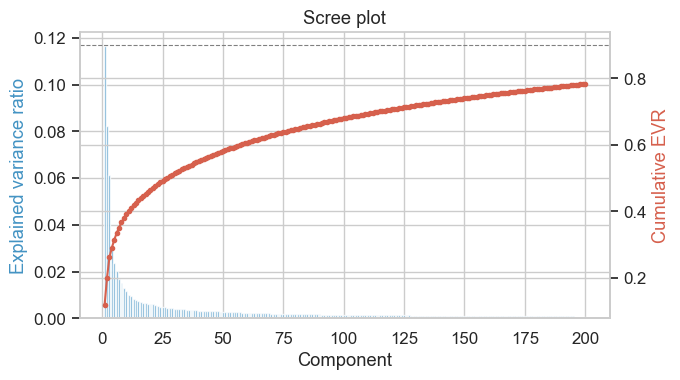

In [22]:
scree = bulk_pipe.decomposer_.scree_data()
fig, ax = plot_scree(scree, max_components=n_components)
plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, "BRCA_scree.pdf"), bbox_inches="tight")
plt.show()


## 8. Phase 2 -- Single-cell pipeline

In [23]:
adata_bulk_pp = bulk_pipe.preprocessor_.transform(adata_bulk)


In [24]:
sc_pipe = SingleCellPipeline(
    bulk_pipeline    = bulk_pipe,
    alignment_method = "moment_matching",
)


In [25]:
print(adata_sc.X.shape)
print(type(adata_sc.X))
import scipy.sparse as sp
print(sp.issparse(adata_sc.X))


(200128, 26684)
<class 'scipy.sparse._csr.csr_matrix'>
True


In [26]:
sc_pipe.fit(adata_bulk_pp, adata_sc)


20:13:49 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.fit ===
20:13:49 | INFO     | scope.preprocessing.single_cell — SingleCellPreprocessor fitted.
20:15:48 | INFO     | scope.utils.gene_utils — Gene universe: 16214 shared, 4316 bulk-only, 10470 sc-only
20:17:13 | INFO     | scope.preprocessing.alignment — BulkSCAligner fitted (method=moment_matching, n_genes=16214).
20:17:13 | INFO     | scope.pipeline.sc_pipeline — SingleCellPipeline.fit complete.


,bulk_pipeline,BulkPipeline(...method='none')
,sc_filter_strategy,'both'
,sc_min_counts,200
,sc_min_genes,200
,sc_target_sum,10000.0
,alignment_method,'moment_matching'
,clip_percentile,99.0
,layer,None
,add_to_obs,True
,norm_method,'none'
,log1p,False


In [28]:
import inspect
from scope.pipeline import SingleCellPipeline
print(inspect.getsource(SingleCellPipeline.transform))


    def transform(self, adata_sc: AnnData) -> AnnData:
        """Project single-cell data into bulk latent space and infer mutations.

        This is the main inference method. It:

        1. QC-filters cells.
        2. Normalises and log-transforms sc expression.
        3. Subsets to the bulk gene universe.
        4. Aligns sc distribution to bulk.
        5. Projects cells into the bulk latent space.
        6. Applies trained mutation classifiers to get per-cell probabilities.
        7. Writes probabilities to ``adata_sc.obs``.

        Parameters
        ----------
        adata_sc:
            Raw (or minimally preprocessed) single-cell AnnData.

        Returns
        -------
        AnnData
            Copy with:

            * ``obsm[bulk_pipeline.obsm_key_]`` — latent embedding.
            * ``obs[mutation_prob_<gene>]`` — per-cell mutation probabilities.
        """
        log.info("=== SingleCellPipeline.transform ===")
        bp = self.bulk_pipeline

        # ──

In [27]:
print(adata_sc.X.shape)
print(type(adata_sc.X))
import scipy.sparse as sp
print(sp.issparse(adata_sc.X))


(200128, 26684)
<class 'scipy.sparse._csr.csr_matrix'>
True


In [ ]:
adata_sc = sc_pipe.transform(adata_sc)


In [ ]:
mut_prob_cols = [c for c in adata_sc.obs.columns if c.startswith("mutation_prob_")]
print(f"Inferred mutation probability columns: {mut_prob_cols}")


## 9. Visualisation

In [ ]:
adata_sc = compute_umap(adata_sc, obsm_key="X_svd")


In [ ]:
ct_col = next((c for c in adata_sc.obs.columns
               if "celltype" in c.lower() or "cell_type" in c.lower()), "sample_id")

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
sc.pl.umap(adata_sc, color=ct_col,      ax=axes[0], show=False, title="Cell type")
sc.pl.umap(adata_sc, color="sample_id", ax=axes[1], show=False, title="Patient")
plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, "BRCA_umap_celltype.pdf"), bbox_inches="tight")
plt.show()


In [ ]:
print(adata_sc)


In [ ]:
sc.pl.umap(adata_sc, color="subtype", show=True, title="Subtype")


In [ ]:
sc.pl.umap(adata_sc, color="celltype_subset", show=True, title="celltype_subset")


In [ ]:
sc.pl.umap(adata_sc, color="celltype_minor", show=True, title="celltype_minor")


In [ ]:
sc.pl.umap(adata_sc, color="celltype_major", show=True, title="celltype_major")


In [ ]:
top_muts = (
    mutation_labels.sum().sort_values(ascending=False).index.tolist()
)
fig = plot_mutation_probabilities(adata_sc, mutations=top_muts)
fig.savefig(os.path.join(MODELS_DIR, "BRCA_mutation_probs.pdf"), bbox_inches="tight")
plt.show()


In [ ]:
top_muts = mutation_labels.sum().sort_values(ascending=False).index.tolist()

prob_cols = [f"mutation_prob_{g}" for g in top_muts if f"mutation_prob_{g}" in adata_sc.obs.columns]

# Per-gene vmax at 99th percentile -- keeps each panel's colorbar meaningful
vmaxes = {c: max(float(np.percentile(adata_sc.obs[c].values, 99)), 0.0005) for c in prob_cols}

ncols = 3
nrows = int(np.ceil(len(prob_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(prob_cols):
    gene = col.replace("mutation_prob_", "")
    sc.pl.umap(
        adata_sc,
        color=col,
        ax=axes[i],
        show=False,
        title=f"P({gene} mut)",
        vmin=0,
        vmax=vmaxes[col],
        cmap="RdBu_r",
        colorbar_loc="right",
        s=2,
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, "BRCA_mutation_probs.pdf"), bbox_inches="tight")
plt.show()


In [ ]:
fig, ax = plot_mutation_heatmap(adata_sc, cluster_key=ct_col, mutations=top_muts)
fig.set_size_inches(30, 12)  # width, height in inches
fig.savefig(os.path.join(MODELS_DIR, "BRCA_heatmap.pdf"), bbox_inches="tight")
plt.show()


In [ ]:
import seaborn as sns
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

def plot_mutation_cooccurrence(mutation_labels, title="Mutation Co-occurrence", 
                                min_freq=5, method="jaccard", figsize=(12, 10)):
    """
    Parameters
    ----------
    mutation_labels : pd.DataFrame
        Binary matrix (samples x genes)
    min_freq : int
        Minimum mutation count to include gene
    method : str
        'jaccard'  — co-occurrence as Jaccard index (size-normalized)
        'phi'      — phi coefficient (correlation on binary vars)
        'log_odds' — log odds ratio from Fisher's exact test
    """
    # Filter low-frequency mutations
    freq = mutation_labels.sum()
    mat  = mutation_labels.loc[:, freq >= min_freq].astype(int)
    genes = mat.columns.tolist()
    n     = len(genes)
    
    # Build co-occurrence matrix
    cooc  = np.zeros((n, n))
    pvals = np.ones((n, n))
    
    for i, g1 in enumerate(genes):
        for j, g2 in enumerate(genes):
            a = mat[g1].values
            b = mat[g2].values
            
            if method == "jaccard":
                intersection = (a & b).sum()
                union        = (a | b).sum()
                cooc[i, j]   = intersection / union if union > 0 else 0
                
            elif method == "phi":
                # Phi coefficient = Pearson on binary
                cooc[i, j] = np.corrcoef(a, b)[0, 1]
                
            elif method == "log_odds":
                # 2x2 contingency
                tp = (a & b).sum()
                fp = (~a.astype(bool) & b.astype(bool)).sum()
                fn = (a.astype(bool) & ~b.astype(bool)).sum()
                tn = (~a.astype(bool) & ~b.astype(bool)).sum()
                table = [[tp, fp], [fn, tn]]
                _, p  = fisher_exact(table)
                pvals[i, j] = p
                or_val = (tp * tn) / (fp * fn) if (fp * fn) > 0 else np.nan
                cooc[i, j] = np.log2(or_val) if or_val and or_val > 0 else 0

    cooc_df = pd.DataFrame(cooc, index=genes, columns=genes)
    
    # FDR correction for log_odds
    annot_df = None
    if method == "log_odds":
        flat_p = pvals[np.triu_indices(n, k=1)]
        _, qvals, _, _ = multipletests(flat_p, method='fdr_bh')
        sig = np.ones((n, n), dtype=bool)
        idx = np.triu_indices(n, k=1)
        sig[idx] = qvals < 0.05
        sig = sig | sig.T
        annot_df = pd.DataFrame(
            np.where(sig, "", "ns"), index=genes, columns=genes
        )
    
    # Sort by mutation frequency descending
    order    = mat.sum().sort_values(ascending=False).index
    cooc_df  = cooc_df.loc[order, order]
    freq_sorted = mat.sum()[order]
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    cmap   = "RdBu_r" if method in ("phi", "log_odds") else "YlOrRd"
    center = 0         if method in ("phi", "log_odds") else None
    
    sns.heatmap(
        cooc_df,
        ax        = ax,
        cmap      = cmap,
        center    = center,
        square    = True,
        linewidths= 0.5,
        linecolor = "white",
        annot     = annot_df.loc[order, order] if annot_df is not None else False,
        fmt       = "",
        cbar_kws  = {"shrink": 0.8, "label": method},
    )
    
    # Annotate diagonal with frequencies
    for k, gene in enumerate(order):
        ax.text(k + 0.5, k + 0.5, str(int(freq_sorted[gene])),
                ha="center", va="center", fontsize=7,
                color="white", fontweight="bold")
    
    ax.set_title(f"{title}\n(diagonal = mutation count, min_freq ≥ {min_freq})",
                 fontsize=13, pad=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    return fig

# --- BRCA (paste into that notebook, mutation_labels will refer to BRCA's) ---
fig_brca = plot_mutation_cooccurrence(
    mutation_labels,
    title   = "BRCA Mutation Co-occurrence",
    min_freq= 5,
    method  = "phi",
)
fig_brca.savefig(os.path.join(MODELS_DIR, "BRCA_mutation_cooccurrence.pdf"), bbox_inches="tight")
plt.show()


In [ ]:
Vt         = bulk_pipe.decomposer_.components_   # (n_components, n_genes)
gene_names = adata_bulk_pp.var_names             # must match gene order in Vt

#adata_bulk_pp = bulk_pipe.preprocessor_.transform(adata_bulk)


In [ ]:
def plot_mutation_clustermap(
    gene,
    Vt,
    gene_names,
    bulk_pipe,
    adata_bulk,
    adata_sc,
    mutation_labels,
    n_genes=50,
    figsize=(18, 12),
    sc_ct_col="cell_type",
):
    from scipy.stats import zscore
    from matplotlib.patches import Patch

    # ── 1. Weighted gene loadings ─────────────────────────────────────────
    clf      = bulk_pipe.classifier_set_.classifiers_[gene]
    coefs    = clf._clf.coef_[0]
    weighted = pd.Series((Vt * coefs[:, None]).sum(axis=0), index=gene_names)

    top_genes = weighted.sort_values(ascending=False).head(n_genes).index
    bot_genes = weighted.sort_values(ascending=True ).head(n_genes).index
    sel_genes = top_genes.tolist() + bot_genes.tolist()

    # ── 2. Pull expression matrices ───────────────────────────────────────
    bulk_genes = adata_bulk.var_names.tolist()
    sc_genes   = adata_sc.var_names.tolist()
    sel_shared = [g for g in sel_genes if g in bulk_genes and g in sc_genes]

    X_bulk = pd.DataFrame(
        adata_bulk[:, sel_shared].X,
        index=adata_bulk.obs_names, columns=sel_shared,
    )
    X_sc = pd.DataFrame(
        adata_sc[:, sel_shared].X,
        index=adata_sc.obs_names, columns=sel_shared,
    )

    # ── 3. Z-score, drop near-constant genes, fill NaNs ──────────────────
    Z_bulk = pd.DataFrame(
        zscore(X_bulk, axis=0), index=X_bulk.index, columns=X_bulk.columns
    ).clip(-3, 3)
    Z_sc = pd.DataFrame(
        zscore(X_sc, axis=0), index=X_sc.index, columns=X_sc.columns
    ).clip(-3, 3)

    valid_genes = (
        Z_bulk.columns[Z_bulk.notna().all(axis=0)]
        .intersection(Z_sc.columns[Z_sc.notna().all(axis=0)])
    )
    Z_bulk = Z_bulk[valid_genes].fillna(0)
    Z_sc   = Z_sc[valid_genes].fillna(0)

    print(f"[{gene}] {len(sel_shared)} selected genes → {len(valid_genes)} after dropping near-constant")

    bulk_sample = Z_bulk.sample(min(200, len(Z_bulk)), random_state=42)
    sc_sample   = Z_sc.sample(  min(300, len(Z_sc)),   random_state=42)
    Z_combined  = pd.concat([bulk_sample, sc_sample], axis=0)

    # ── 4. Row colour bars ────────────────────────────────────────────────
    source_labels = ["Bulk"] * len(bulk_sample) + ["SC"] * len(sc_sample)
    source_pal    = {"Bulk": "#2C7BB6", "SC": "#D7191C"}
    row_source    = pd.Series(source_labels, index=Z_combined.index).map(source_pal)

    mut_status = []
    for idx in Z_combined.index:
        if idx in bulk_sample.index:
            barcode = idx[:15]
            if barcode in mutation_labels.index and gene in mutation_labels.columns:
                mut_status.append(int(mutation_labels.loc[barcode, gene]))
            else:
                mut_status.append(np.nan)
        else:
            mut_status.append(np.nan)

    mut_pal = {1: "#B2182B", 0: "#4393C3"}
    row_mut = pd.Series(mut_status, index=Z_combined.index).map(
        lambda x: mut_pal.get(x, "#CCCCCC")
    )

    if sc_ct_col in adata_sc.obs.columns:
        ct_vals = adata_sc.obs[sc_ct_col]
        ct_cats = ct_vals.unique()
        ct_pal  = dict(zip(ct_cats, sns.color_palette("tab20", len(ct_cats))))
        row_ct  = pd.Series(
            [ct_pal.get(ct_vals.get(i, None), "#CCCCCC") for i in Z_combined.index],
            index=Z_combined.index,
        )
        row_colors = pd.DataFrame({
            "Source":     row_source,
            "Mut status": row_mut,
            "Cell type":  row_ct,
        })
    else:
        row_colors = pd.DataFrame({
            "Source":     row_source,
            "Mut status": row_mut,
        })

    # ── 5. Column colour bar ──────────────────────────────────────────────
    color_map = {g: "#B2182B" for g in top_genes if g in valid_genes}
    color_map.update({g: "#2166AC" for g in bot_genes if g in valid_genes})
    col_colors = pd.Series(
        [color_map[g] for g in valid_genes],
        index=valid_genes,
        name="Loading direction",
    )

    # ── 6. Clustermap ─────────────────────────────────────────────────────
    g = sns.clustermap(
        Z_combined,
        row_colors      = row_colors,
        col_colors      = col_colors,
        cmap            = "RdBu_r",
        center          = 0,
        vmin=-3, vmax=3,
        figsize         = figsize,
        xticklabels     = True,
        yticklabels     = False,
        row_cluster     = True,
        col_cluster     = True,
        dendrogram_ratio= (0.1, 0.02),
        colors_ratio    = 0.02,
        cbar_pos        = (0.02, 0.82, 0.03, 0.08),
        linewidths      = 0,
    )
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=6
    )

    # ── 7. Fix top gap by manually repositioning axes ─────────────────────
    heatmap_pos   = g.ax_heatmap.get_position()
    col_color_pos = g.ax_col_colors.get_position()
    col_dend_pos  = g.ax_col_dendrogram.get_position()

    gap         = 0.005
    dend_height = 0.03

    # Pin color bar flush to top of heatmap
    g.ax_col_colors.set_position([
        col_color_pos.x0,
        heatmap_pos.y1 + gap,
        col_color_pos.width,
        col_color_pos.height,
    ])
    # Pin dendrogram flush above color bar
    g.ax_col_dendrogram.set_position([
        col_dend_pos.x0,
        heatmap_pos.y1 + col_color_pos.height + gap * 2,
        col_dend_pos.width,
        dend_height,
    ])

    g.fig.suptitle(
        f"{gene} — top/bottom {n_genes} predictive genes\n"
        f"(red col = positive loading, blue col = negative loading)",
        y=0.95, fontsize=16,
    )
    g.fig.subplots_adjust(top=0.90)

    # ── 8. Legend ─────────────────────────────────────────────────────────
    legend_elements = [
        Patch(facecolor="#2C7BB6", label="Bulk"),
        Patch(facecolor="#D7191C", label="SC"),
        Patch(facecolor="#B2182B", label=f"{gene} mutated"),
        Patch(facecolor="#4393C3", label=f"{gene} WT"),
        Patch(facecolor="#CCCCCC", label="Unknown / SC"),
    ]
    g.ax_heatmap.legend(
        handles=legend_elements, bbox_to_anchor=(1.25, 1.1),
        loc="upper left", frameon=True, fontsize=8,
    )
    return g
    

In [ ]:
for gene in ['TP53', 'PIK3CA', 'CDH1', 'GATA3', 'MAP3K1']:  # swap for your BRCA genes
    g = plot_mutation_clustermap(
        gene            = gene,
        Vt              = Vt,                    # from brca bulk_pipe.decomposer_.components_
        gene_names      = gene_names,            # from brca adata_bulk_pp.var_names
        bulk_pipe       = bulk_pipe,             # your BRCA bulk_pipe
        adata_bulk      = adata_bulk,            # BRCA bulk AnnData
        adata_sc        = adata_sc,              # BRCA SC AnnData
        mutation_labels = mutation_labels,       # BRCA mutation matrix
        n_genes         = 50,
        sc_ct_col       = "cell_type",           # adjust to BRCA SC obs column
    )
    g.fig.savefig(
        os.path.join(MODELS_DIR, f"BRCA_{gene}_clustermap.pdf"),
        bbox_inches="tight", dpi=150,
    )
    plt.show()
    

In [ ]:
import anndata as ad
import pandas as pd
from scope import BulkPipeline
from scope.io import load_mutation_labels
from scope.evaluation import SVDEvaluator

# ── Get Z_bulk ──────────────────────────────────────────────────────────────
adata_pp = bulk_pipe.transform_bulk(adata_bulk)
Z_bulk = adata_pp.obsm[bulk_pipe.obsm_key_]

# ── Run SVDEvaluator for each mutation ──────────────────────────────────────
mutations = list(bulk_pipe.classifier_set_.classifiers_.keys())
print(f"Mutations to evaluate: {mutations}")

for mutation in mutations:
    print(f"\n── Evaluating {mutation} ──")
    ev = SVDEvaluator(bulk_pipe, Z_bulk, mutation=mutation)
    ev.run_all(
        output_dir=f"./results/BRCA/figures/svd_eval_{mutation}",
        cv=5,
        n_permutations=200,
    )
    print(f"  ✓ Saved to figures/svd_eval_{mutation}/")
